# **1. Perkenalan Dataset**

Nama Dataset: Ulasan Aplikasi DANA

Sumber: *Google Play Store (Scraping)*

Format: CSV

Tujuan: Analisis sentimen (positive, neutral, negative)

Kolom utama: reviewId, userName, content, score, thumbsUpCount, at, replyContent, repliedAt, appVersion

# **2. Import Library**

In [1]:
%pip install sastrawi wordcloud nltk

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from pathlib import Path

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab')
nltk.download('stopwords', quiet=True)

plt.style.use('default')
sns.set_palette('husl')

print('✓ Semua library berhasil diimport')

✓ Semua library berhasil diimport


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Pongo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **3. Memuat Dataset**

In [3]:
from pathlib import Path

base_path = Path('..')
data_path = base_path / 'ulasan-aplikasi-dana_raw' / 'ulasan-aplikasi-dana.csv'

print('Memuat dataset dari:', data_path)
df = pd.read_csv(data_path, on_bad_lines='skip')

print('\n5 baris pertama dataset:')
print(df.head())

print('\nBentuk dataset:')
print('Baris:', df.shape[0], 'Kolom:', df.shape[1])

print('\nNama kolom:')
print(df.columns.tolist())

Memuat dataset dari: ..\ulasan-aplikasi-dana_raw\ulasan-aplikasi-dana.csv

5 baris pertama dataset:
                               reviewId         userName  \
0  16bc4ff0-c19a-4648-b823-f00ebed4a941  Pengguna Google   
1  cf942823-a2ca-40b4-8a3e-8a4cbc464431  Pengguna Google   
2  4bb89160-664f-4550-bbae-cd26de32b319  Pengguna Google   
3  5a8015c3-ddff-40eb-8b6c-4ebcd1dcc5fe  Pengguna Google   
4  57690ef7-468a-4eb9-a7fe-eaf0efce6543  Pengguna Google   

                                           userImage  \
0  https://play-lh.googleusercontent.com/EGemoI2N...   
1  https://play-lh.googleusercontent.com/EGemoI2N...   
2  https://play-lh.googleusercontent.com/EGemoI2N...   
3  https://play-lh.googleusercontent.com/EGemoI2N...   
4  https://play-lh.googleusercontent.com/EGemoI2N...   

                                             content  score  thumbsUpCount  \
0  sering terjadi bug dan lambat, sinyal bagus ta...      3              5   
1  pengaturan terbaru, agak menyusahkan, seper

# **4. Exploratory Data Analysis (EDA)**

In [4]:
print('✓ Info Dataset:')
print(df.info())

✓ Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65000 entries, 0 to 64999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              65000 non-null  object
 1   userName              65000 non-null  object
 2   userImage             65000 non-null  object
 3   content               65000 non-null  object
 4   score                 65000 non-null  int64 
 5   thumbsUpCount         65000 non-null  int64 
 6   reviewCreatedVersion  54220 non-null  object
 7   at                    65000 non-null  object
 8   replyContent          52583 non-null  object
 9   repliedAt             52583 non-null  object
 10  appVersion            54220 non-null  object
dtypes: int64(2), object(9)
memory usage: 5.5+ MB
None


In [5]:
print('✓ Statistik Deskriptif:')
print(df.describe())

✓ Statistik Deskriptif:
              score  thumbsUpCount
count  65000.000000   65000.000000
mean       2.264185      11.256108
std        1.629318     145.586341
min        1.000000       0.000000
25%        1.000000       0.000000
50%        1.000000       0.000000
75%        4.000000       0.000000
max        5.000000    8645.000000


In [8]:
print('✓ Nilai Kosong (Missing Values):')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal nilai kosong: {missing.sum()}')

✓ Nilai Kosong (Missing Values):
reviewCreatedVersion    10780
replyContent            12417
repliedAt               12417
appVersion              10780
dtype: int64

Total nilai kosong: 46394


✓ Distribusi Skor:
score
1    35920
2     6557
3     5423
4     3631
5    13469
Name: count, dtype: int64


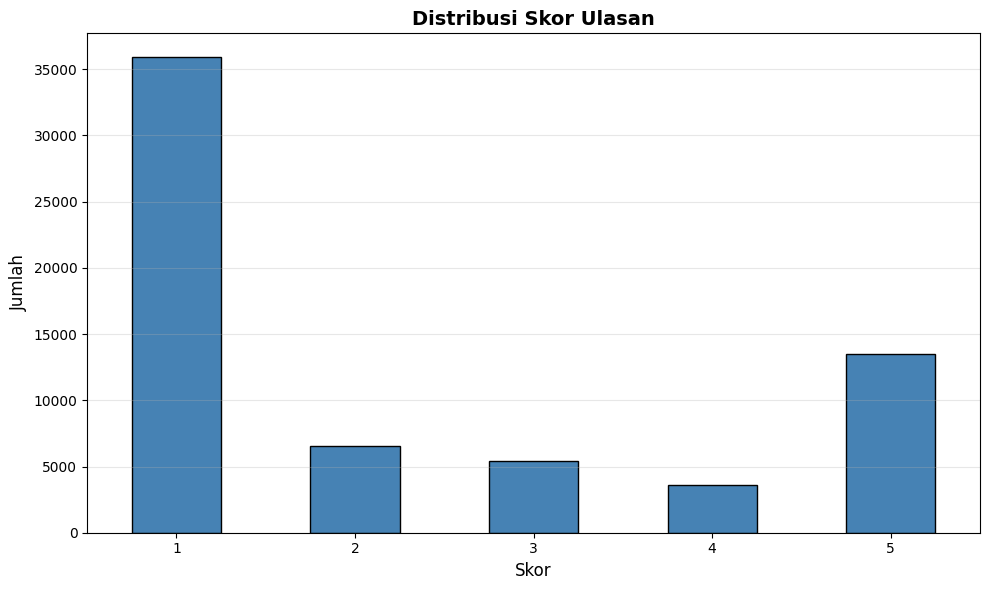

In [9]:
print('✓ Distribusi Skor:')
score_counts = df['score'].value_counts().sort_index()
print(score_counts)

plt.figure(figsize=(10, 6))
score_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Skor Ulasan', fontsize=14, fontweight='bold')
plt.xlabel('Skor', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

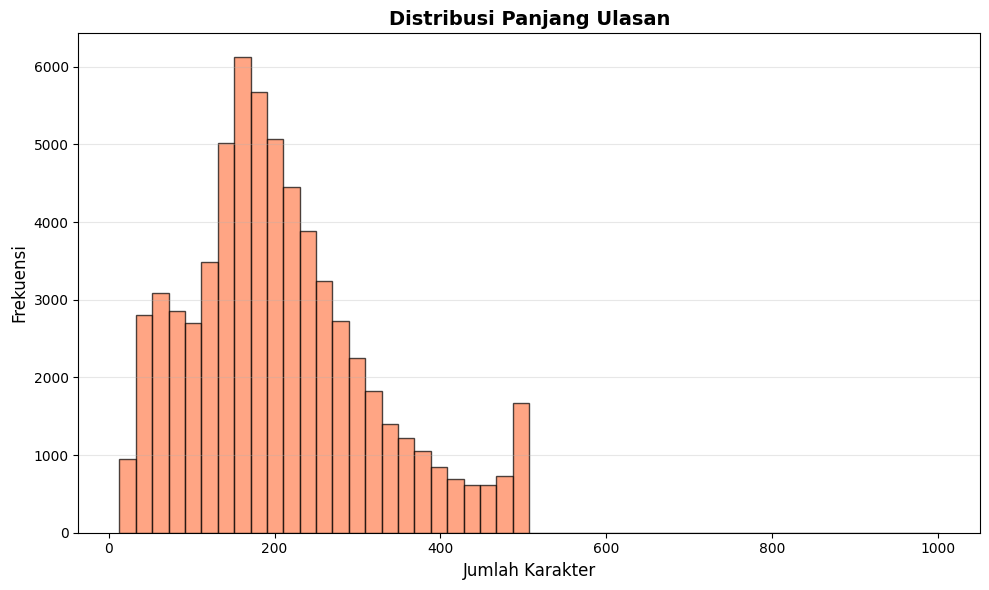

✓ Rata-rata panjang ulasan: 207.19 karakter
✓ Panjang ulasan minimum: 13 karakter
✓ Panjang ulasan maksimum: 1001 karakter


In [10]:
df['review_length'] = df['content'].fillna('').str.len()

plt.figure(figsize=(10, 6))
plt.hist(df['review_length'], bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.title('Distribusi Panjang Ulasan', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Karakter', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'✓ Rata-rata panjang ulasan: {df["review_length"].mean():.2f} karakter')
print(f'✓ Panjang ulasan minimum: {df["review_length"].min()} karakter')
print(f'✓ Panjang ulasan maksimum: {df["review_length"].max()} karakter')

In [12]:
print('✓ Contoh 5 Ulasan Pertama:')
for idx in range(min(5, len(df))):
    print(f'Ulasan {idx+1}:')
    print(f'Skor: {df.iloc[idx]["score"]}')
    print(f'Isi: {df.iloc[idx]["content"]}')
    print('-'*80)

✓ Contoh 5 Ulasan Pertama:
Ulasan 1:
Skor: 3
Isi: sering terjadi bug dan lambat, sinyal bagus tapi aplikasi nya patah patah saat di gunakan,update rutin tapi tidak ngaruh ke pemeliharaan akun,dan sering error saat mau cek transaksi mau pun saat kirim uang dengan nomor handphone
--------------------------------------------------------------------------------
Ulasan 2:
Skor: 2
Isi: pengaturan terbaru, agak menyusahkan, seperti memaksa customer untuk deposit 2x dan dikenakan admin top up 2x. dulu bagus. sekarang kinerja maulai turun. untuk aset investasi rasa gantung. skrg banyak gk nyamannya. terutama fitur baru, Bi Fast. jika nomor itu sdh digunakan direkening pada bank. saat tranfer malah akan error karena sdh terdaftar di rekening bukan dana. karena memaksakan fitur baru tapi tidak matang, hasil nya adalah jelek.
--------------------------------------------------------------------------------
Ulasan 3:
Skor: 5
Isi: Aplikasi DANA menurut saya sangat membantu dalam kehidupan sehari-hari

# **5. Data Preprocessing**

### Menangani Nilai Kosong

In [13]:
print('✓ Langkah 1: Tangani Nilai Kosong')
print(f'Bentuk dataset sebelum: {df.shape}')

df_clean = df.dropna(subset=['content']).copy()
df_clean = df_clean[df_clean['content'].str.strip() != ''].copy()

print(f'Bentuk dataset setelah menghapus isi kosong: {df_clean.shape}')
print(f'Baris dihapus: {df.shape[0] - df_clean.shape[0]}')

✓ Langkah 1: Tangani Nilai Kosong
Bentuk dataset sebelum: (65000, 12)
Bentuk dataset setelah menghapus isi kosong: (65000, 12)
Baris dihapus: 0


### Menangani Duplikat

In [14]:
print('✓ Langkah 2: Tangani Duplikat')
print(f'Bentuk dataset sebelum: {df_clean.shape}')

df_clean = df_clean.drop_duplicates(subset=['content'], keep='first').reset_index(drop=True)

print(f'Bentuk dataset setelah menghapus duplikat: {df_clean.shape}')
print(f'Baris dihapus: {len(df) - len(df_clean)}')

✓ Langkah 2: Tangani Duplikat
Bentuk dataset sebelum: (65000, 12)
Bentuk dataset setelah menghapus duplikat: (64931, 12)
Baris dihapus: 69


In [16]:
def bersihkan_teks(text):
    """
    Bersihkan teks dengan menerapkan beberapa langkah preprocessing:
    - Ubah ke huruf kecil
    - Hapus URL
    - Hapus mention dan hashtag
    - Hapus karakter non-alfabet (hanya a-z dan spasi)
    - Hapus spasi berlebih
    
    Args:
        text (str): Teks mentah untuk dibersihkan
        
    Returns:
        str: Teks yang telah dibersihkan
    """
    if pd.isna(text):
        return ''
    
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print('✓ Langkah 3: Pembersihan Teks')
df_clean['text_cleaned'] = df_clean['content'].apply(bersihkan_teks)

print('Sampel teks bersih (3 pertama):')
for idx in range(min(3, len(df_clean))):
    print(f'Asli: {df_clean.iloc[idx]["content"]}')
    print(f'Bersih: {df_clean.iloc[idx]["text_cleaned"]}')
    print('-'*80)

✓ Langkah 3: Pembersihan Teks
Sampel teks bersih (3 pertama):
Asli: sering terjadi bug dan lambat, sinyal bagus tapi aplikasi nya patah patah saat di gunakan,update rutin tapi tidak ngaruh ke pemeliharaan akun,dan sering error saat mau cek transaksi mau pun saat kirim uang dengan nomor handphone
Bersih: sering terjadi bug dan lambat sinyal bagus tapi aplikasi nya patah patah saat di gunakanupdate rutin tapi tidak ngaruh ke pemeliharaan akundan sering error saat mau cek transaksi mau pun saat kirim uang dengan nomor handphone
--------------------------------------------------------------------------------
Asli: pengaturan terbaru, agak menyusahkan, seperti memaksa customer untuk deposit 2x dan dikenakan admin top up 2x. dulu bagus. sekarang kinerja maulai turun. untuk aset investasi rasa gantung. skrg banyak gk nyamannya. terutama fitur baru, Bi Fast. jika nomor itu sdh digunakan direkening pada bank. saat tranfer malah akan error karena sdh terdaftar di rekening bukan dana. karena mema

### Tokenisasi

In [17]:
print('✓ Langkah 4: Tokenisasi')
df_clean['tokens'] = df_clean['text_cleaned'].apply(lambda x: word_tokenize(x) if x else [])

print('Sampel token (3 pertama):')
for idx in range(min(3, len(df_clean))):
    print(f'Teks bersih: {df_clean.iloc[idx]["text_cleaned"]}')
    print(f'Token: {df_clean.iloc[idx]["tokens"]}')
    print('-'*80)

✓ Langkah 4: Tokenisasi
Sampel token (3 pertama):
Teks bersih: sering terjadi bug dan lambat sinyal bagus tapi aplikasi nya patah patah saat di gunakanupdate rutin tapi tidak ngaruh ke pemeliharaan akundan sering error saat mau cek transaksi mau pun saat kirim uang dengan nomor handphone
Token: ['sering', 'terjadi', 'bug', 'dan', 'lambat', 'sinyal', 'bagus', 'tapi', 'aplikasi', 'nya', 'patah', 'patah', 'saat', 'di', 'gunakanupdate', 'rutin', 'tapi', 'tidak', 'ngaruh', 'ke', 'pemeliharaan', 'akundan', 'sering', 'error', 'saat', 'mau', 'cek', 'transaksi', 'mau', 'pun', 'saat', 'kirim', 'uang', 'dengan', 'nomor', 'handphone']
--------------------------------------------------------------------------------
Teks bersih: pengaturan terbaru agak menyusahkan seperti memaksa customer untuk deposit x dan dikenakan admin top up x dulu bagus sekarang kinerja maulai turun untuk aset investasi rasa gantung skrg banyak gk nyamannya terutama fitur baru bi fast jika nomor itu sdh digunakan direkening p

### Stopwords

In [ ]:
print('✓ Langkah 5: Stopwords')
stop_words = set(stopwords.words('indonesian'))

def remove_stopwords(tokens):
    """
    Hapus stopwords dari daftar token dan filter token dengan panjang > 1.
    
    Args:
        tokens (list): Daftar token
        
    Returns:
        list: Token yang telah difilter
    """
    return [token for token in tokens if token not in stop_words and len(token) > 1]

df_clean['tokens_no_stopwords'] = df_clean['tokens'].apply(remove_stopwords)

print('Sampel token setelah hapus stopwords (3 pertama):')
for idx in range(min(3, len(df_clean))):
    print(f'Dengan stopwords: {df_clean.iloc[idx]["tokens"]}')
    print(f'Tanpa stopwords: {df_clean.iloc[idx]["tokens_no_stopwords"]}')
    print('-'*80)

✓ Langkah 5: Hapus Stopwords
Sampel token setelah hapus stopwords (3 pertama):
Dengan stopwords: ['sering', 'terjadi', 'bug', 'dan', 'lambat', 'sinyal', 'bagus', 'tapi', 'aplikasi', 'nya', 'patah', 'patah', 'saat', 'di', 'gunakanupdate', 'rutin', 'tapi', 'tidak', 'ngaruh', 'ke', 'pemeliharaan', 'akundan', 'sering', 'error', 'saat', 'mau', 'cek', 'transaksi', 'mau', 'pun', 'saat', 'kirim', 'uang', 'dengan', 'nomor', 'handphone']
Tanpa stopwords: ['bug', 'lambat', 'sinyal', 'bagus', 'aplikasi', 'nya', 'patah', 'patah', 'gunakanupdate', 'rutin', 'ngaruh', 'pemeliharaan', 'akundan', 'error', 'cek', 'transaksi', 'kirim', 'uang', 'nomor', 'handphone']
--------------------------------------------------------------------------------
Dengan stopwords: ['pengaturan', 'terbaru', 'agak', 'menyusahkan', 'seperti', 'memaksa', 'customer', 'untuk', 'deposit', 'x', 'dan', 'dikenakan', 'admin', 'top', 'up', 'x', 'dulu', 'bagus', 'sekarang', 'kinerja', 'maulai', 'turun', 'untuk', 'aset', 'investasi', 'ra

### Stemming

In [20]:
print('✓ Langkah 6: Stemming')
stemmer = StemmerFactory().create_stemmer()

def stem_tokens(tokens):
    """
    Terapkan stemming pada daftar token menggunakan stemmer Sastrawi Indonesia.
    
    Args:
        tokens (list): Daftar token
        
    Returns:
        list: Token yang telah di-stem
    """
    return [stemmer.stem(token) for token in tokens]

df_clean['tokens_stemmed'] = df_clean['tokens_no_stopwords'].apply(stem_tokens)

print('Sampel token setelah stemming (3 pertama):')
for idx in range(min(3, len(df_clean))):
    print(f'Sebelum stemming: {df_clean.iloc[idx]["tokens_no_stopwords"]}')
    print(f'Sesudah stemming: {df_clean.iloc[idx]["tokens_stemmed"]}')
    print('-'*80)

✓ Langkah 6: Stemming
Sampel token setelah stemming (3 pertama):
Sebelum stemming: ['bug', 'lambat', 'sinyal', 'bagus', 'aplikasi', 'nya', 'patah', 'patah', 'gunakanupdate', 'rutin', 'ngaruh', 'pemeliharaan', 'akundan', 'error', 'cek', 'transaksi', 'kirim', 'uang', 'nomor', 'handphone']
Sesudah stemming: ['bug', 'lambat', 'sinyal', 'bagus', 'aplikasi', 'nya', 'patah', 'patah', 'gunakanupdate', 'rutin', 'ngaruh', 'pelihara', 'akundan', 'error', 'cek', 'transaksi', 'kirim', 'uang', 'nomor', 'handphone']
--------------------------------------------------------------------------------
Sebelum stemming: ['pengaturan', 'terbaru', 'menyusahkan', 'memaksa', 'customer', 'deposit', 'dikenakan', 'admin', 'top', 'up', 'bagus', 'kinerja', 'maulai', 'turun', 'aset', 'investasi', 'gantung', 'skrg', 'gk', 'nyamannya', 'fitur', 'bi', 'fast', 'nomor', 'sdh', 'direkening', 'bank', 'tranfer', 'error', 'sdh', 'terdaftar', 'rekening', 'dana', 'memaksakan', 'fitur', 'matang', 'hasil', 'nya', 'jelek']
Sesudah

### Penggabungan Token

In [21]:
print('✓ Langkah 7: Gabungkan Token')
df_clean['text_akhir'] = df_clean['tokens_stemmed'].apply(lambda x: ' '.join(x))

print('Sampel teks akhir (3 pertama):')
for idx in range(min(3, len(df_clean))):
    print(f'Token: {df_clean.iloc[idx]["tokens_stemmed"]}')
    print(f'Teks akhir: {df_clean.iloc[idx]["text_akhir"]}')
    print('-'*80)

✓ Langkah 7: Gabungkan Token
Sampel teks akhir (3 pertama):
Token: ['bug', 'lambat', 'sinyal', 'bagus', 'aplikasi', 'nya', 'patah', 'patah', 'gunakanupdate', 'rutin', 'ngaruh', 'pelihara', 'akundan', 'error', 'cek', 'transaksi', 'kirim', 'uang', 'nomor', 'handphone']
Teks akhir: bug lambat sinyal bagus aplikasi nya patah patah gunakanupdate rutin ngaruh pelihara akundan error cek transaksi kirim uang nomor handphone
--------------------------------------------------------------------------------
Token: ['atur', 'baru', 'susah', 'paksa', 'customer', 'deposit', 'kena', 'admin', 'top', 'up', 'bagus', 'kerja', 'maulai', 'turun', 'aset', 'investasi', 'gantung', 'skrg', 'gk', 'nyaman', 'fitur', 'bi', 'fast', 'nomor', 'sdh', 'rekening', 'bank', 'tranfer', 'error', 'sdh', 'daftar', 'rekening', 'dana', 'paksa', 'fitur', 'matang', 'hasil', 'nya', 'jelek']
Teks akhir: atur baru susah paksa customer deposit kena admin top up bagus kerja maulai turun aset investasi gantung skrg gk nyaman fitur bi f

### Visualisasi WordCloud

✓ Langkah 8: Visualisasi WordCloud


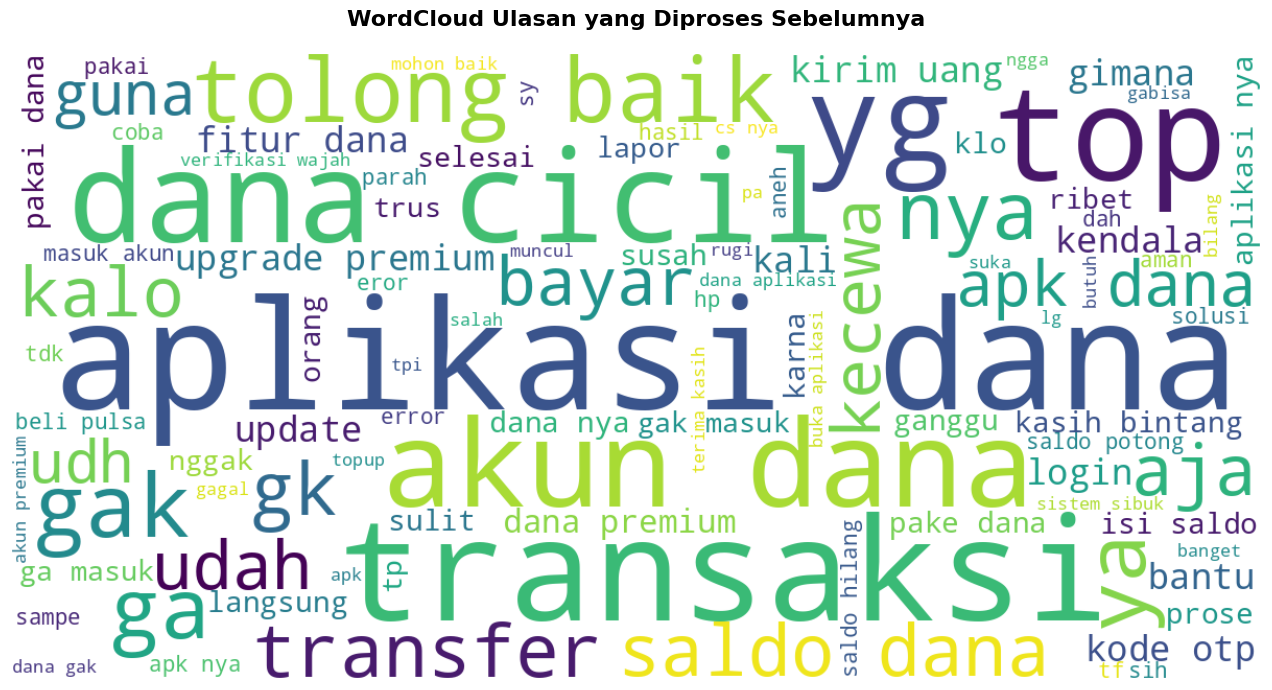

✓ WordCloud berhasil dibuat


In [22]:
print('✓ Langkah 8: Visualisasi WordCloud')

all_text = ' '.join(df_clean['text_akhir'].tolist())

wordcloud = WordCloud(width=1200, height=600, 
                        background_color='white',
                        colormap='viridis',
                        max_words=100).generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Ulasan yang Diproses Sebelumnya', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('✓ WordCloud berhasil dibuat')

# **6. Pelabelan Data dengan Lexicon-based**

In [23]:
print('✓ Memuat lexicon untuk analisis sentimen aplikasi')

# Load dari file CSV
lexicon_path = Path('lexicon/lexicon_dana.csv')
df_lexicon = pd.read_csv(lexicon_path)

# Pisahkan positif dan negatif
positive_lexicon = df_lexicon[df_lexicon['sentimen'] == 'positif']['kata'].tolist()
negative_lexicon = df_lexicon[df_lexicon['sentimen'] == 'negatif']['kata'].tolist()

print(f'Lexicon berhasil dimuat')
print(f'Kata positif: {len(positive_lexicon)}')
print(f'Kata negatif: {len(negative_lexicon)}')

✓ Memuat lexicon untuk analisis sentimen aplikasi
Lexicon berhasil dimuat
Kata positif: 114
Kata negatif: 130


In [24]:
def sentiment_analysis_lexicon_indonesia(text):
    """
    Lakukan analisis sentimen menggunakan pendekatan berbasis lexicon.
    Kembalikan skor sentimen dan polarity (positive, neutral, negative).
    
    Args:
        text (str): Teks yang telah diproses untuk dianalisis
        
    Returns:
        tuple: (sentiment_score, polarity)
    """
    tokens = text.split()
    
    positive_count = sum(1 for token in tokens if token in positive_lexicon)
    negative_count = sum(1 for token in tokens if token in negative_lexicon)
    
    sentiment_score = positive_count - negative_count
    
    if sentiment_score > 0:
        polarity = 'positive'
    elif sentiment_score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'
    
    return sentiment_score, polarity

print('✓ Menerapkan analisis sentimen...')
df_clean[['sentiment_score', 'polarity']] = df_clean['text_akhir'].apply(
    lambda x: pd.Series(sentiment_analysis_lexicon_indonesia(x))
)

print('✓ Analisis sentimen selesai')
print('\nSampel hasil (5 pertama):')
print(df_clean[['text_akhir', 'sentiment_score', 'polarity']].head())

✓ Menerapkan analisis sentimen...
✓ Analisis sentimen selesai

Sampel hasil (5 pertama):
                                          text_akhir  sentiment_score  \
0  bug lambat sinyal bagus aplikasi nya patah pat...               -2   
1  atur baru susah paksa customer deposit kena ad...                0   
2  aplikasi dana bantu hidup seharihari tampil se...                4   
3  buruk fitur dana instan akun premium hubung an...                1   
4  sih bagus yaa kalo bayar pake qris qris nya su...                3   

   polarity  
0  negative  
1   neutral  
2  positive  
3  positive  
4  positive  


In [26]:
print('✓ Distribusi Sentimen:')
sentiment_counts = df_clean['polarity'].value_counts()
print(sentiment_counts)
print('\nPersentase:')
print(df_clean['polarity'].value_counts(normalize=True) * 100)

✓ Distribusi Sentimen:
polarity
neutral     24999
positive    22143
negative    17789
Name: count, dtype: int64

Persentase:
polarity
neutral     38.500870
positive    34.102355
negative    27.396775
Name: proportion, dtype: float64


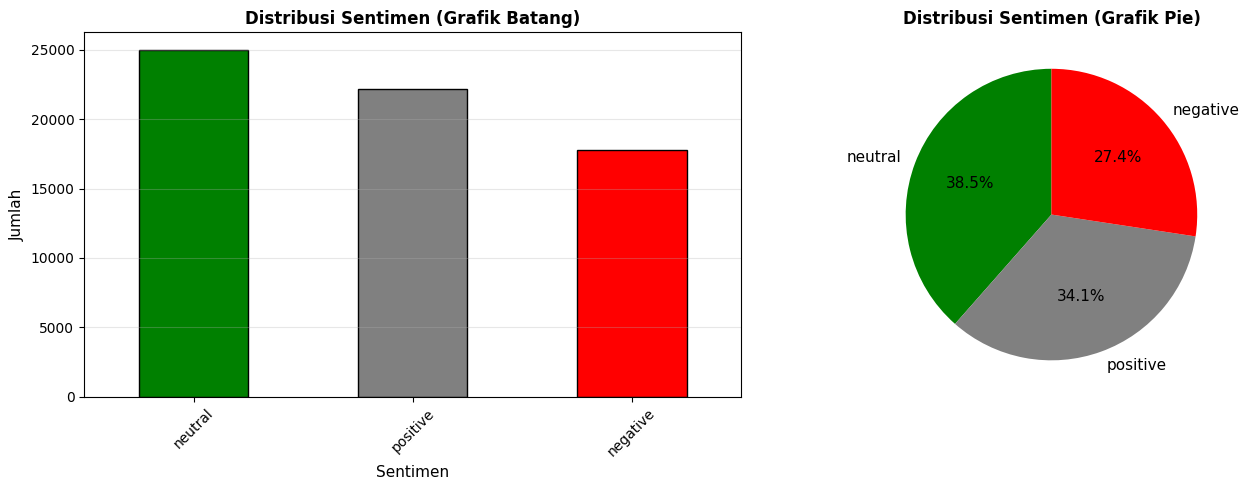

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts.plot(kind='bar', ax=axes[0], color=['green', 'gray', 'red'], edgecolor='black')
axes[0].set_title('Distribusi Sentimen (Grafik Batang)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentimen', fontsize=11)
axes[0].set_ylabel('Jumlah', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

colors = ['green', 'gray', 'red']
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Distribusi Sentimen (Grafik Pie)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

✓ WordCloud untuk Ulasan Positif


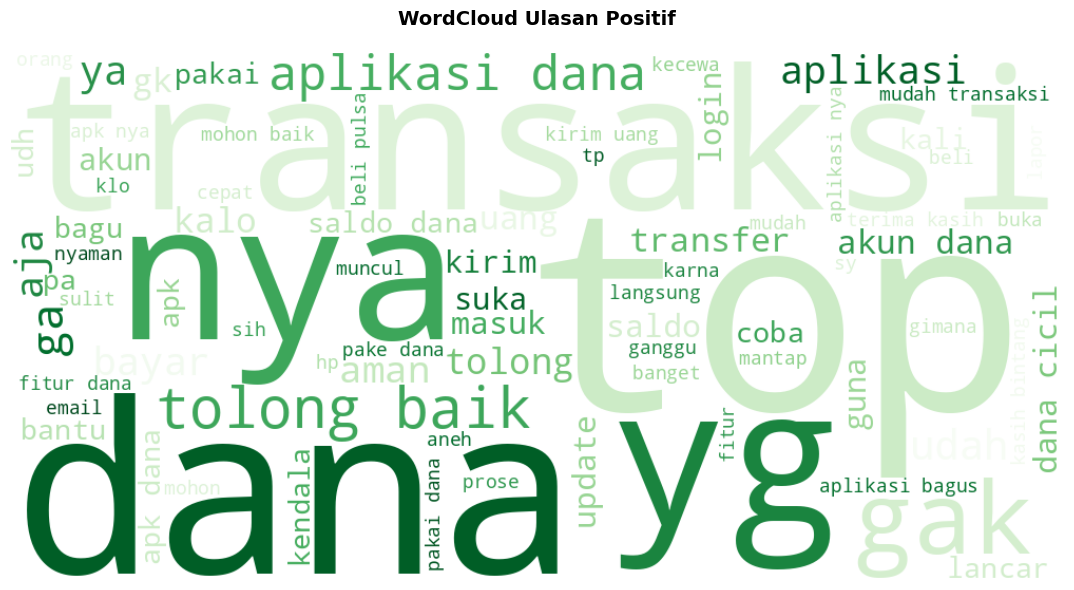

In [28]:
print('✓ WordCloud untuk Ulasan Positif')
positive_text = ' '.join(df_clean[df_clean['polarity'] == 'positive']['text_akhir'].tolist())

if positive_text.strip():
    wordcloud_pos = WordCloud(width=1000, height=500,
                            background_color='white',
                            colormap='Greens',
                            max_words=80).generate(positive_text)
    
    plt.figure(figsize=(14, 6))
    plt.imshow(wordcloud_pos, interpolation='bilinear')
    plt.axis('off')
    plt.title('WordCloud Ulasan Positif', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada ulasan positif')

✓ WordCloud untuk Ulasan Negatif


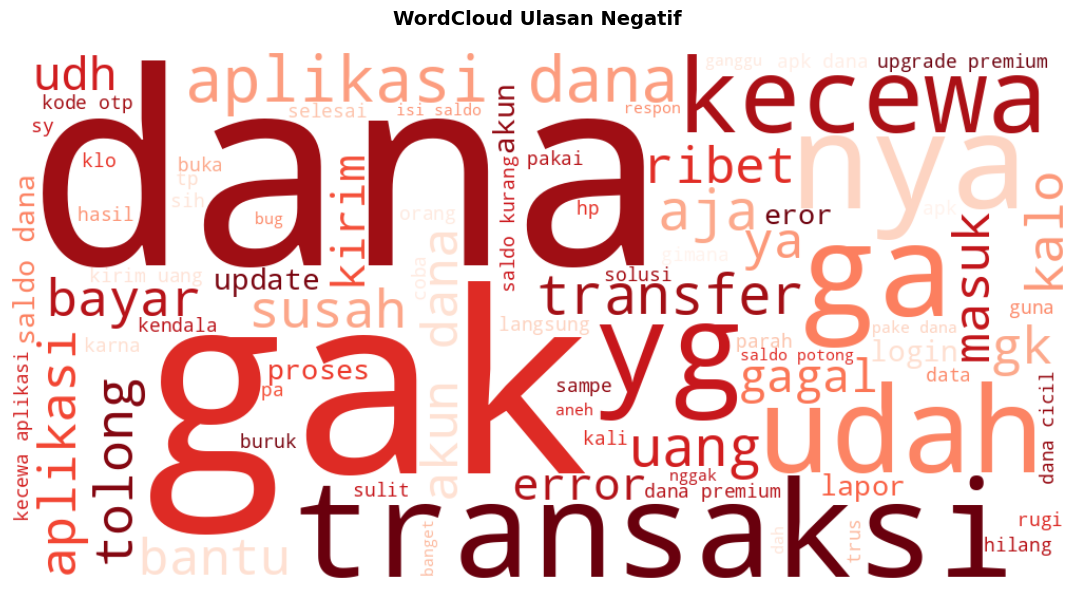

In [29]:
print('✓ WordCloud untuk Ulasan Negatif')
negative_text = ' '.join(df_clean[df_clean['polarity'] == 'negative']['text_akhir'].tolist())

if negative_text.strip():
    wordcloud_neg = WordCloud(width=1000, height=500,
                            background_color='white',
                            colormap='Reds',
                            max_words=80).generate(negative_text)
    
    plt.figure(figsize=(14, 6))
    plt.imshow(wordcloud_neg, interpolation='bilinear')
    plt.axis('off')
    plt.title('WordCloud Ulasan Negatif', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada ulasan negatif')

# **7. Split Data Train/Validation/Test**

In [30]:
print('✓ Mempersiapkan data untuk pembagian')
X = df_clean['text_akhir'].values
y = df_clean['polarity'].values

print(f'Total sampel: {len(X)}')
print(f'Distribusi kelas: {pd.Series(y).value_counts().to_dict()}')

✓ Mempersiapkan data untuk pembagian
Total sampel: 64931
Distribusi kelas: {'neutral': 24999, 'positive': 22143, 'negative': 17789}


In [31]:
print('✓ Membagi data: 70% train, 15% validasi, 15% test')

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f'\nUkuran set train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Ukuran set validasi: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)')
print(f'Ukuran set test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)')

✓ Membagi data: 70% train, 15% validasi, 15% test

Ukuran set train: 45451 (70.0%)
Ukuran set validasi: 9740 (15.0%)
Ukuran set test: 9740 (15.0%)


In [32]:
print('✓ Verifikasi distribusi kelas:')
print('\nSet pelatihan:')
train_dist = pd.Series(y_train).value_counts()
print(train_dist)
print((train_dist / len(y_train) * 100).round(2))

print('\nSet validasi:')
val_dist = pd.Series(y_val).value_counts()
print(val_dist)
print((val_dist / len(y_val) * 100).round(2))

print('\nSet pengujian:')
test_dist = pd.Series(y_test).value_counts()
print(test_dist)
print((test_dist / len(y_test) * 100).round(2))

✓ Verifikasi distribusi kelas:

Set pelatihan:
neutral     17499
positive    15500
negative    12452
Name: count, dtype: int64
neutral     38.5
positive    34.1
negative    27.4
Name: count, dtype: float64

Set validasi:
neutral     3750
positive    3322
negative    2668
Name: count, dtype: int64
neutral     38.50
positive    34.11
negative    27.39
Name: count, dtype: float64

Set pengujian:
neutral     3750
positive    3321
negative    2669
Name: count, dtype: int64
neutral     38.5
positive    34.1
negative    27.4
Name: count, dtype: float64


# **8. Menyimpan Hasil Preprocessing**

In [33]:
output_dir = Path('..') / 'preprocessing' / 'ulasan-aplikasi-dana_preprocessing'
output_dir.mkdir(parents=True, exist_ok=True)

print(f'✓ Direktori output: {output_dir}')
print(f'Direktori ada: {output_dir.exists()}')

✓ Direktori output: ..\preprocessing\ulasan-aplikasi-dana_preprocessing
Direktori ada: True


In [34]:
preprocessed_data = df_clean[['content', 'score', 'text_akhir', 'polarity', 'sentiment_score']].copy()
preprocessed_data.to_csv(output_dir / 'data_preprocessed.csv', index=False)

print(f'✓ Tersimpan: data_preprocessed.csv - {preprocessed_data.shape[0]} baris')

✓ Tersimpan: data_preprocessed.csv - 64931 baris


In [35]:
pd.DataFrame(X_train, columns=['text']).to_csv(output_dir / 'X_train.csv', index=False)
pd.DataFrame(X_val, columns=['text']).to_csv(output_dir / 'X_val.csv', index=False)
pd.DataFrame(X_test, columns=['text']).to_csv(output_dir / 'X_test.csv', index=False)

pd.DataFrame(y_train, columns=['polarity']).to_csv(output_dir / 'y_train.csv', index=False)
pd.DataFrame(y_val, columns=['polarity']).to_csv(output_dir / 'y_val.csv', index=False)
pd.DataFrame(y_test, columns=['polarity']).to_csv(output_dir / 'y_test.csv', index=False)

print('✓ Split Train/Validasi/Test tersimpan sebagai CSV')

✓ Split Train/Validasi/Test tersimpan sebagai CSV


# **9. Summary Preprocessing**

In [37]:
print('='*80)
print('RINGKASAN PREPROCESSING')
print('='*80)

print('\n✓ Perbandingan Bentuk Data:')
print(f'  Dataset asli: {df.shape[0]} baris, {df.shape[1]} kolom')
print(f'  Setelah preprocessing: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom')
print(f'  Baris yang dipertahankan: {df_clean.shape[0]} ({(df_clean.shape[0]/df.shape[0]*100):.1f}%)')

print('\n✓ Tahap Preprocessing yang Diterapkan:')
stages = [
    'Tangani nilai kosong (hapus isi kosong)',
    'Tangani duplikat (hapus isi duplikat)',
    'Pembersihan teks (huruf kecil, hapus URL, mentions, karakter khusus)',
    'Tokenisasi (pisahkan menjadi kata)',
    'Penghapusan stopwords (stopwords Indonesia, panjang > 1)',
    'Stemming (stemmer Sastrawi)',
    'Penggabungan token (buat teks akhir)',
    'Pelabelan sentimen (analisis berbasis lexicon)',
    'Pemisahan data (70% train, 15% val, 15% test dengan stratifikasi)'
]
for i, stage in enumerate(stages, 1):
    print(f'  {i}. ✓ {stage}')

print('\n✓ File Output yang Dibuat:')
output_files = [
    'data_preprocessed.csv',
    'data_preprocessed.parquet',
    'X_train.csv, X_val.csv, X_test.csv',
    'y_train.csv, y_val.csv, y_test.csv',
]
for f in output_files:
    print(f'  ✓ {f}')

print(f'\n✓ Direktori output: {output_dir}')

print('\n✓ Statistik Pembagian Data:')
total_samples = len(X_train) + len(X_val) + len(X_test)
print(f'  Train: {len(X_train)} sampel ({len(X_train)/total_samples*100:.1f}%)')
print(f'  Validasi: {len(X_val)} sampel ({len(X_val)/total_samples*100:.1f}%)')
print(f'  Test: {len(X_test)} sampel ({len(X_test)/total_samples*100:.1f}%)')

print('\n✓ Distribusi Sentimen (Dataset Akhir):')
for sentiment in ['positive', 'negative', 'neutral']:
    count = (df_clean['polarity'] == sentiment).sum()
    pct = (count / len(df_clean) * 100) if len(df_clean) > 0 else 0
    print(f'  ✓ {sentiment}: {count} ({pct:.1f}%)')

print('\n' + '='*80)
print('✓ Preprocessing selesai!')

RINGKASAN PREPROCESSING

✓ Perbandingan Bentuk Data:
  Dataset asli: 65000 baris, 12 kolom
  Setelah preprocessing: 64931 baris, 19 kolom
  Baris yang dipertahankan: 64931 (99.9%)

✓ Tahap Preprocessing yang Diterapkan:
  1. ✓ Tangani nilai kosong (hapus isi kosong)
  2. ✓ Tangani duplikat (hapus isi duplikat)
  3. ✓ Pembersihan teks (huruf kecil, hapus URL, mentions, karakter khusus)
  4. ✓ Tokenisasi (pisahkan menjadi kata)
  5. ✓ Penghapusan stopwords (stopwords Indonesia, panjang > 1)
  6. ✓ Stemming (stemmer Sastrawi)
  7. ✓ Penggabungan token (buat teks akhir)
  8. ✓ Pelabelan sentimen (analisis berbasis lexicon)
  9. ✓ Pemisahan data (70% train, 15% val, 15% test dengan stratifikasi)

✓ File Output yang Dibuat:
  ✓ data_preprocessed.csv
  ✓ data_preprocessed.parquet
  ✓ X_train.csv, X_val.csv, X_test.csv
  ✓ y_train.csv, y_val.csv, y_test.csv

✓ Direktori output: ..\preprocessing\ulasan-aplikasi-dana_preprocessing

✓ Statistik Pembagian Data:
  Train: 45451 sampel (70.0%)
  Vali